# Business Background
In this project, I built machine learning models to predict whether a credit card customer is likely to default on their payment.  


**core business question is:**

Can we predict whether a customer will default on their credit card payment based on their financial behavior and demographic information?
If banks can accurately identify customers who are likely to default, they can:
- adjust credit limits
- manage lending risk
- and design better credit policies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import recall_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Data Loading

In [2]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\425 final project\\default of credit card clients.csv")
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [3]:
df = pd.read_csv("C:\\Users\\User\\Desktop\\425 final project\\default of credit card clients.csv",header=1)
# rename columns
df.columns = [
    "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
    "default_payment_next_month"
]
# drop ID
df.drop(columns=["ID"], inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
df.shape

(30000, 24)

In [5]:
# Checking for missing values
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default_payment_next_month    0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

# Raw data and field descriptions

- **LIMIT_BAL**: Credit limit (NTD), including personal consumption credit and supplementary credit for family.
- **SEX**: Gender, where:
  - `1` = Male
  - `2` = Female
- **EDUCATION**: Education level, where:
  - `1` = Graduate school
  - `2` = University
  - `3` = High school
  - `4` = Others (including unknown, etc.)
- **MARRIAGE**: Marital status, where:
  - `1` = Married
  - `2` = Single
  - `3` = Others (including unknown status)
- **AGE**: Age (years).
- **PAY_0** - **PAY_6**: Historical repayment records (April to September 2005):
  - `-1` = Paid on time
  - `1` = Payment delayed by 1 month
  - `2` = Payment delayed by 2 months
  - `...`
  - `9` = Payment delayed by 9 months or more
- **BILL_AMT1 - BILL_AMT6**: Bill amounts (NTD) for April to September 2005.
- **PAY_AMT1 - PAY_AMT6**: Payment amounts (NTD) for April to September 2005.
- **default_payment_next_month**: Whether there is a credit card default in the next month, where:
  - `1` = Default
  - `0` = No default

# Data Processing

In [7]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
print(df["SEX"].unique())
print(df["EDUCATION"].unique())
print(df["MARRIAGE"].unique())

[2 1]
[2 1 3 5 4 6 0]
[1 2 3 0]


## Treatment of categorical variables

In [9]:
df["SEX"] = df["SEX"] - 1  
# 0 means male, 1 means female
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})  
# 1 means graduate, 2 means undergraduate, 3 means high school, 4 means other
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})  
# 1 means married, 2 means single, 3 means other

In [10]:
# For Logistic Regression: One-Hot Encoding for categorical variables
df_lr = pd.get_dummies(df, columns=["EDUCATION", "MARRIAGE"], drop_first=True)
df_lr.head()

,LIMIT_BAL,SEX,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,1,24,2,2,-1,-1,-2,-2,3913,...,0,0,0,0,1,True,False,False,False,False
1,120000,1,26,-1,2,0,0,0,2,2682,...,1000,1000,0,2000,1,True,False,False,True,False
2,90000,1,34,0,0,0,0,0,0,29239,...,1000,1000,1000,5000,0,True,False,False,True,False
3,50000,1,37,0,0,0,0,0,0,46990,...,1200,1100,1069,1000,0,True,False,False,False,False
4,50000,0,57,-1,0,-1,0,0,0,8617,...,10000,9000,689,679,0,True,False,False,False,False


In [11]:
# For XGBoost: new version directly supported categorical variables
df_xgb = df.copy()
df_xgb["SEX"] = df_xgb["SEX"].astype("category")
df_xgb["EDUCATION"] = df_xgb["EDUCATION"].astype("category")
df_xgb["MARRIAGE"] = df_xgb["MARRIAGE"].astype("category")
df_xgb.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment_next_month
0,20000,1,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,1,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,1,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,1,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,0,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [12]:
X_lr = df_lr.drop(columns=["default_payment_next_month"])
X_xgb = df_xgb.drop(columns=["default_payment_next_month"])
y = df["default_payment_next_month"]

In [13]:
X_train_lr, X_test_lr, y_train, y_test = train_test_split(X_lr, y, test_size=0.2, random_state=425, stratify=y)
X_train_xgb, X_test_xgb, y_train, y_test = train_test_split(X_xgb, y, test_size=0.2, random_state=425, stratify=y) 

## Treatment of numerical variables

In [14]:
# Logistic Regression: standardization
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

## Treatment of explanatory variable

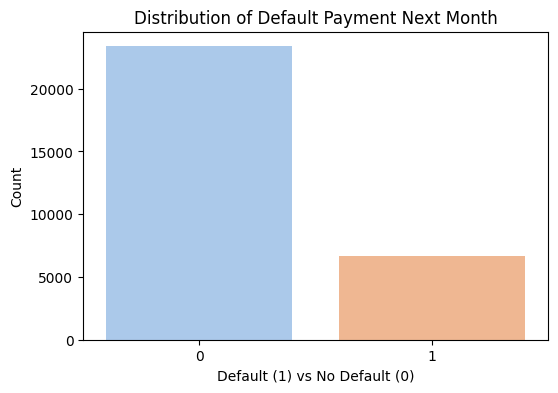

In [15]:
# whether categories are balanced
plt.figure(figsize=(6, 4))
sns.countplot(x=df["default_payment_next_month"], palette="pastel")
plt.title("Distribution of Default Payment Next Month")
plt.xlabel("Default (1) vs No Default (0)")
plt.ylabel("Count")
plt.show()

In [16]:
# For logistical regression: Using SMOTE to deal with category imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=425)
X_train_lr_scaled_resampled, y_train_resampled = smote.fit_resample(X_train_lr_scaled, y_train)
X_train_xgb_resampled, _ = smote.fit_resample(X_train_xgb, y_train)  # No duplicate creation y_train_resampled 

# Model Choose

**Logistic Regression** is a widely used baseline model in credit risk modeling. It is relatively simple and interpretable, which is important in financial applications where regulators often require model transparency.

**XGBoost**, on the other hand, is a more complex tree-based ensemble method that can capture nonlinear relationships and interactions between variables.


# Model Training and Feature Importance

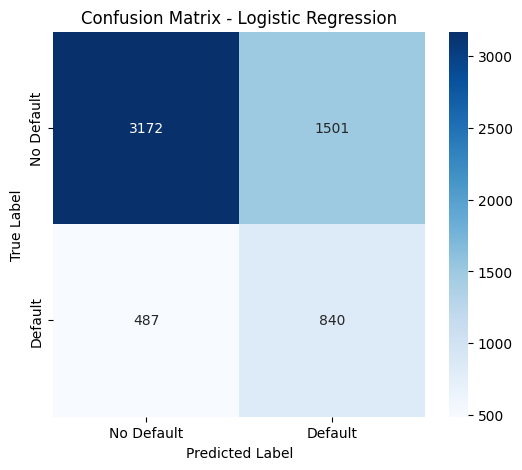


Model: Logistic Regression
              precision    recall  f1-score   support

           0     0.8669    0.6788    0.7614      4673
           1     0.3588    0.6330    0.4580      1327

    accuracy                         0.6687      6000
   macro avg     0.6129    0.6559    0.6097      6000
weighted avg     0.7545    0.6687    0.6943      6000

Recall (Default Class): 0.6330
F1 Score (Default Class): 0.4580
ROC AUC Score: 0.6559


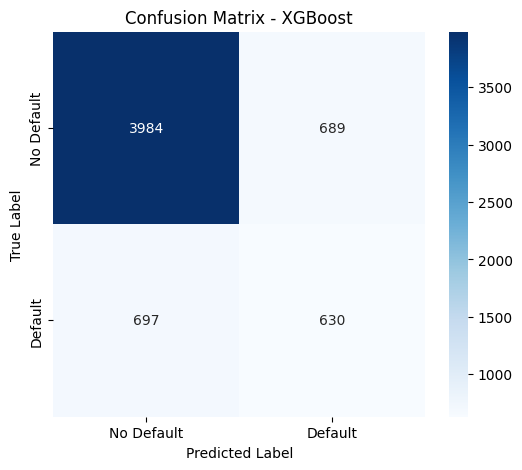


Model: XGBoost
              precision    recall  f1-score   support

           0     0.8511    0.8526    0.8518      4673
           1     0.4776    0.4748    0.4762      1327

    accuracy                         0.7690      6000
   macro avg     0.6644    0.6637    0.6640      6000
weighted avg     0.7685    0.7690    0.7687      6000

Recall (Default Class): 0.4748
F1 Score (Default Class): 0.4762
ROC AUC Score: 0.6637

Final Model Comparison:
                 Model  Recall (Default)  F1 Score (Default)   ROC AUC
0  Logistic Regression          0.633007            0.458015  0.655900
1              XGBoost          0.474755            0.476190  0.663656


In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=425),
    "XGBoost": XGBClassifier(tree_method="hist", enable_categorical=True, random_state=425)
}

results = []
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_lr_scaled_resampled, y_train_resampled)
        y_pred = model.predict(X_test_lr_scaled)  
    else:
        model.fit(X_train_xgb_resampled, y_train_resampled) 
        y_pred = model.predict(X_test_xgb) 
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Default", "Default"], yticklabels=["No Default", "Default"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
    # Calculating performance metrics
    recall_default = recall_score(y_test, y_pred, pos_label=1)
    f1_default = f1_score(y_test, y_pred, pos_label=1)
    roc_auc = roc_auc_score(y_test, y_pred)
    
    # Displaying results clearly for each model
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"Recall (Default Class): {recall_default:.4f}")
    print(f"F1 Score (Default Class): {f1_default:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    
    # Storing the results
    results.append([name, recall_default, f1_default, roc_auc])

# Converting the results to a DataFrame for clear comparison
results_df = pd.DataFrame(results, columns=["Model", "Recall (Default)", "F1 Score (Default)", "ROC AUC"])
print("\nFinal Model Comparison:")
print(results_df)

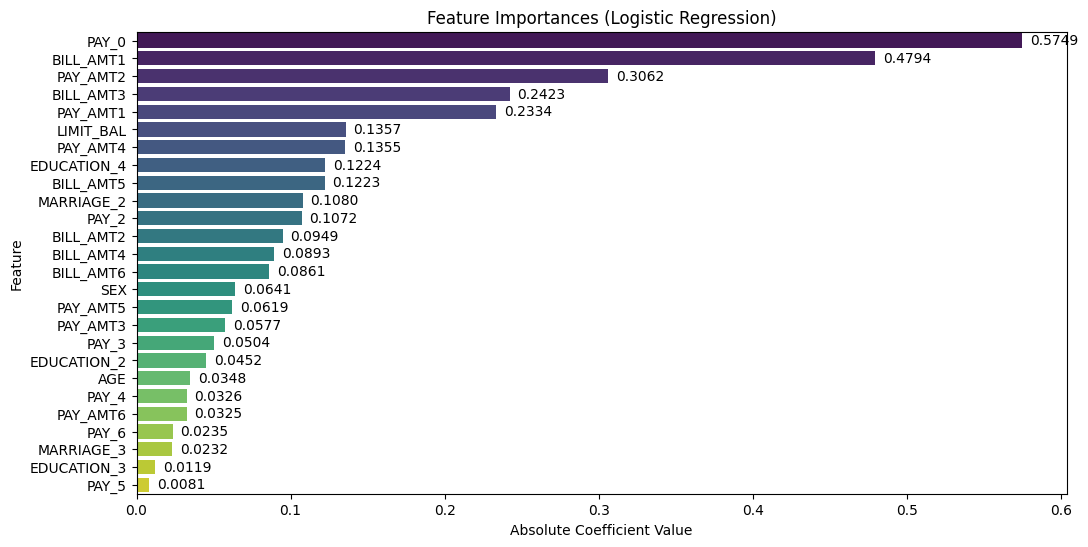

In [18]:
# model 1: logistic regressions - absolute coefficient
feature_names = df_lr.drop(columns=["default_payment_next_month"]).columns

importances_lr = abs(models["Logistic Regression"].coef_[0]) 
feature_importance_lr = pd.DataFrame({"Feature": feature_names, "Importance": importances_lr})
feature_importance_lr = feature_importance_lr.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Importance", y="Feature", data=feature_importance_lr, palette="viridis")
plt.title("Feature Importances (Logistic Regression)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")

for index, value in enumerate(feature_importance_lr["Importance"]):
    ax.text(value + 0.005, index, f"{value:.4f}", color='black', va="center")

plt.show()

**Logistic Regression**  

In the Logistic Regression model, feature importance is measured by the **absolute value of the regression coefficients**. Larger absolute values indicate a **stronger** influence of the feature on predicting credit default risk.  

1. The most influential feature is **PAY_0 (0.5749)**, representing **the most recent repayment status**. This indicates that recent repayment behavior is critical in predicting default.  
2. The second most influential feature is **BILL_AMT1 (0.4794)**, reflecting that **a higher recent bill amount** increases default risk significantly.  
3. Other important features include recent payment amounts like **PAY_AMT2 (0.3062)** and **BILL_AMT3 (0.2423)**, highlighting again that **recent financial behaviors** strongly impact credit default prediction.  

Overall, the Logistic Regression model emphasizes the importance of **recent repayment statuses** and **billing amounts** in assessing default risk.

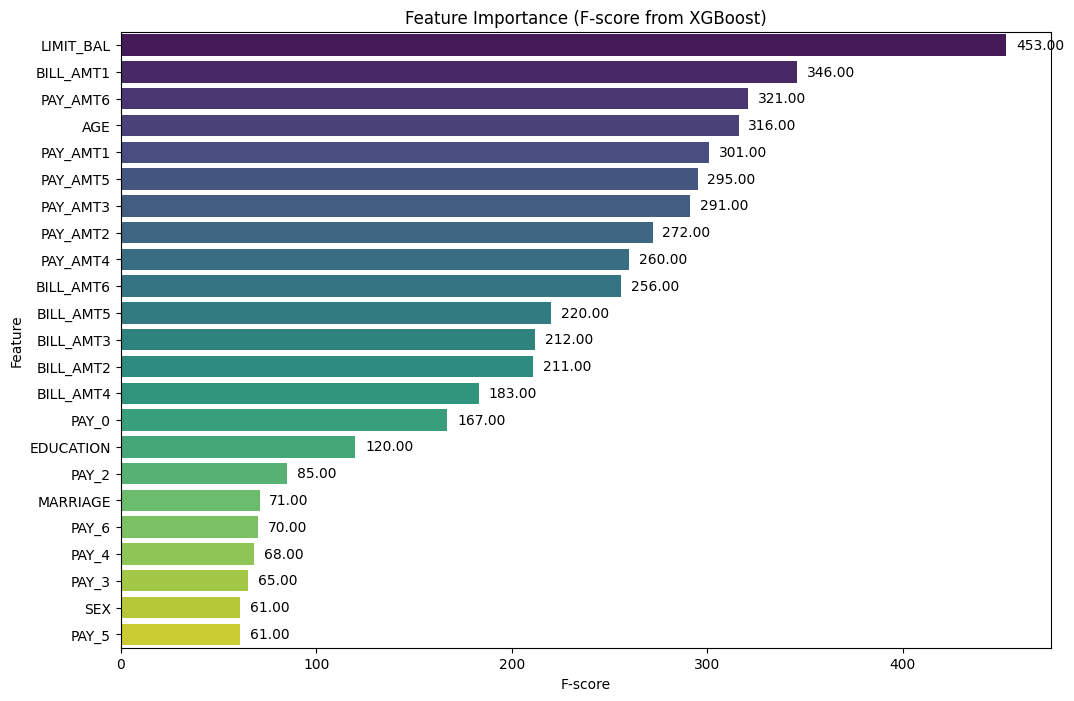

In [19]:
# model 2: XGBoost - F-score
xgb_model = xgb.XGBClassifier(tree_method="hist", enable_categorical=True, eval_metric="auc", random_state=425)
xgb_model.fit(X_train_xgb_resampled, y_train_resampled)

feature_importance_xgb = xgb_model.get_booster().get_score(importance_type="weight")
feature_importance_xgb = pd.DataFrame({
    "Feature": list(feature_importance_xgb.keys()),
    "F-score": list(feature_importance_xgb.values())
}).sort_values(by="F-score", ascending=False)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x="F-score", y="Feature", data=feature_importance_xgb, palette="viridis")
plt.title("Feature Importance (F-score from XGBoost)")
plt.xlabel("F-score")
plt.ylabel("Feature")

for index, value in enumerate(feature_importance_xgb["F-score"]):
    ax.text(value + 5, index, f"{value:.2f}", color='black', va="center")

plt.show()

**XGBoost**  

The XGBoost model measures feature importance using the **F-score**, which represents **the frequency a feature is used for splitting nodes within the model’s decision trees**. A higher F-score suggests the feature contributes more **strongly** to prediction accuracy.  

1. The most critical feature identified by XGBoost is **LIMIT_BAL (F-score: 453)**. This indicates that **the given credit limit** significantly affects a client's default risk.  
2. Following this, **BILL_AMT1 (346)** also appears influential, demonstrating that **recent outstanding amounts** are crucial determinants of default.  
3. Features such as recent payment amounts **PAY_AMT6 (321), AGE (316), and PAY_AMT1 (301)** also show notable importance. These suggest that **payment capacity and demographic attributes (age)** substantially affect the probability of default.  

Compared to Logistic Regression, the XGBoost model leverages **a broader range of information**, including **credit limit, payment behaviors, and age**, providing a more comprehensive view of risk assessment.

# Exploratory Threshold Analysis for Optimizing Recall in Logistic Regression

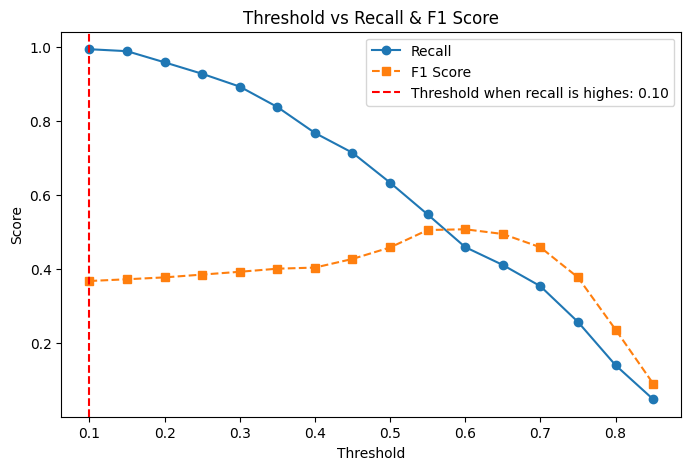

Best Threshold for Maximum Recall: 0.10
Best Recall at this Threshold: 0.9932
F1 Score at this Threshold: 0.3674

Performance with Optimized Threshold:
              precision    recall  f1-score   support

           0     0.9412    0.0308    0.0597      4673
           1     0.2254    0.9932    0.3674      1327

    accuracy                         0.2437      6000
   macro avg     0.5833    0.5120    0.2136      6000
weighted avg     0.7829    0.2437    0.1277      6000



In [20]:
def tune_threshold_for_recall(model, X_test, y_test, thresholds=np.arange(0.1, 0.9, 0.05)):
    """
    Function to find the best threshold for maximizing recall for the default class (1)
    in a logistic regression model.
    """
    y_probs = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
    best_threshold = 0.5  # Default threshold
    best_recall = 0
    best_f1 = 0

    recalls = []
    f1_scores = []
    
    # Iterate over different thresholds
    for threshold in thresholds:
        y_pred_adjusted = (y_probs >= threshold).astype(int)
        recall = recall_score(y_test, y_pred_adjusted, pos_label=1)
        f1 = f1_score(y_test, y_pred_adjusted, pos_label=1)

        recalls.append(recall)
        f1_scores.append(f1)

        if recall > best_recall:  # Optimize for recall
            best_recall = recall
            best_f1 = f1
            best_threshold = threshold

    # Plot recall vs threshold
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, recalls, marker='o', label="Recall", linestyle='-')
    plt.plot(thresholds, f1_scores, marker='s', label="F1 Score", linestyle='--')
    plt.axvline(best_threshold, color='red', linestyle="dashed", label=f"Threshold when recall is highes: {best_threshold:.2f}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title("Threshold vs Recall & F1 Score")
    plt.legend()
    plt.show()

    print(f"Best Threshold for Maximum Recall: {best_threshold:.2f}")
    print(f"Best Recall at this Threshold: {best_recall:.4f}")
    print(f"F1 Score at this Threshold: {best_f1:.4f}")

    return best_threshold

# Call the function after fitting the logistic regression model
best_threshold = tune_threshold_for_recall(models["Logistic Regression"], X_test_lr_scaled, y_test)

# Apply best threshold to make final predictions
y_probs_lr = models["Logistic Regression"].predict_proba(X_test_lr_scaled)[:, 1]
y_pred_best_threshold = (y_probs_lr >= best_threshold).astype(int)

# Evaluate the new predictions
print("\nPerformance with Optimized Threshold:")
print(classification_report(y_test, y_pred_best_threshold, digits=4))

My results show that adjusting the threshold leads to a significant improvement in recall, but at the expense of precision. Future improvements could involve optimizing the threshold based on business-defined cost functions rather than just maximizing recall.

Based on the results, Logistic Regression turns out to be the more suitable model for this credit risk prediction task.

Although XGBoost is generally considered a powerful machine learning algorithm, the simpler Logistic Regression model achieved higher recall and provides better interpretability.

In financial institutions, model transparency is important because lending decisions often need to be explained to regulators and customers.